In [1]:
import pandas as pd
from ast import literal_eval
import json 
whole_plot_reference_df = pd.read_json('D:/narana/notebooks/same_story_books/whole_plot_reference.jsonl', lines=True)
extracted_reddit_posts = pd.read_json('D:/DP/adal/data/solved_books_split/extracted_titles_google_gemini_2.5_pro_exp_03_25_free.jsonl', lines=True)
extracted_reddit_posts = extracted_reddit_posts.explode("extracted_titles")["extracted_titles"].apply(pd.Series)
extracted_titles = extracted_reddit_posts.drop_duplicates(subset=["title", "comment_id"])


def load_wiki_plots_dataset(dir_path) -> pd.DataFrame:
    with open(dir_path + '/plots.txt', 'r', encoding='utf-8') as file:
        wiki_plots = file.read().split('<EOS>')
        wiki_plots.pop(-1)
    with open(dir_path + '/exclude_titles.txt', 'r', encoding='utf-8') as file:
        exclude_titles = file.read().splitlines()
    with open(dir_path + '/titles.txt', 'r', encoding='utf-8') as file:
        titles = file.read().splitlines()
    assert len(wiki_plots) == len(titles), f"wiki_plots and titles have different lengths: {len(wiki_plots)} != {len(titles)}"
    
    df = pd.DataFrame({'plot': wiki_plots, 'title': titles})
    df = df[~df['title'].isin(exclude_titles)]
    df["plot"] = df["plot"].apply(lambda x: x.strip())
    return df

wiki_plots_df = load_wiki_plots_dataset('D:/DP/data')


In [2]:
extracted_reddit_posts.head()

,title,author,solved,type,comment_id,confidence_score,relevance_score,reason
0,The Outstretched Shadow,Mercedes Lackey and James Mallory,True,book,ceppgja,1.0,1.0,"The book features Kellen, son of an Arch-Mage,..."
1,The Street,Lee Gruenfeld,True,book,cepx2so,1.0,1.0,"The plot involves corrupt brokers, potentially..."
2,A Sleepy Story,Elisabeth Burrowes,True,book,cewpem1,1.0,1.0,The plot of 'A Sleepy Story' involves a nested...
3,The Egypt Game,Zilpha Keatley Snyder,True,book,ceyergq,1.0,0.8,The book involves children creating an elabora...
4,Winds of Mars,H. M. Hoover,True,book,cf3w6rl,1.0,1.0,"The book 'The Winds of Mars' features Annalyn,..."


In [3]:
wiki_plots_df.head()

,plot,title
0,"Old Major, the old boar on the Manor Farm, sum...",Animal Farm
1,Alex is a 15-year-old living in near-future dy...,A Clockwork Orange (novel)
2,The text of The Plague is divided into five pa...,The Plague
3,"Among others, John Heath has observed, ""The un...",Actaeon
4,"An expedition from Straumli Realm, an ambitiou...",A Fire Upon the Deep


In [4]:
whole_plot_reference_df.head()

,match_id,original,title,type,authors,search_queries,similarity,imdb_id
0,match_001,Hamlet,Sons of Anarchy,series,[],[Sons of Anarchy],"Sometimes called the 'biker Hamlet', it follow...",NaN
1,match_002,Hamlet,The Lion King (1994),film,[],"[The Lion King 1994, Lion King]","Evil uncle kills good king father, son overthr...",NaN
2,match_003,Hamlet,The Lion King II: Simba's Pride,film,[],"[The Lion King II, Lion King Simbas Pride]","Listed under The Lion King (1994), its similar...",NaN
3,match_004,Hamlet,The Lion King 1 ½,film,[],"[The Lion King 1 1/2, The Lion King 1.5]","Listed under The Lion King (1994), the descrip...",NaN
4,match_005,Hamlet,The Bad Sleep Well,film,[Kurosawa],"[The Bad Sleep Well, Bad Sleep Well Kurosawa]",Young man gets a prominent position in a corru...,NaN


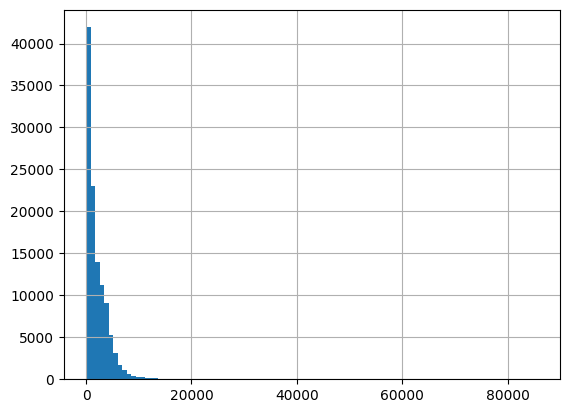

plot     The story starts with an illustration that it ...
title                          Ek Tha Chander Ek Thi Sudha
Name: 105611, dtype: object

In [5]:
from matplotlib import pyplot as plt

wiki_plots_df["plot_length"] = wiki_plots_df["plot"].apply(len)
wiki_plots_df["plot_length"].describe()
wiki_plots_df["plot_length"].hist(bins=100)
plt.show()

wiki_plots_df["plot_length"].describe()


wiki_plots_df[wiki_plots_df["plot_length"] > 80000][["plot", "title"]].iloc[0]

In [6]:
wiki_similar_matches = wiki_plots_df[wiki_plots_df["title"].isin(whole_plot_reference_df["title"])]
print(wiki_plots_df[wiki_plots_df["title"].isin(whole_plot_reference_df["original"])]["title"].tolist())
whole_plot_reference_df[whole_plot_reference_df["title"].isin(wiki_similar_matches["title"])]



["A Midsummer Night's Dream"]


,match_id,original,title,type,authors,search_queries,similarity,imdb_id
2,match_003,Hamlet,The Lion King II: Simba's Pride,film,[],"[The Lion King II, Lion King Simbas Pride]","Listed under The Lion King (1994), its similar...",NaN
4,match_005,Hamlet,The Bad Sleep Well,film,[Kurosawa],"[The Bad Sleep Well, Bad Sleep Well Kurosawa]",Young man gets a prominent position in a corru...,NaN
7,match_008,Hamlet,Strange Brew,film,[],[Strange Brew],"is a fairly low-brow version of Hamlet, with, ...",NaN
8,match_009,Hamlet,The Dead Fathers Club,book,[],[The Dead Fathers Club],is a novel that reimagines the story of Hamlet...,NaN
9,match_010,Hamlet,Wyrd Sisters,book,[Pratchett],"[Wyrd Sisters, Wyrd Sisters Pratchett]","while mostly Macbeth, has a fair chunk of Haml...",NaN
14,match_015,Henry IV,My Own Private Idaho,film,[],[My Own Private Idaho],The story of two hustlers on a journey to find...,NaN
18,match_019,King Lear,A Thousand Acres,book,[],[A Thousand Acres],"King Lear on a Midwestern American farm, where...",NaN
19,match_020,King Lear,Harry and Tonto,film,[],[Harry and Tonto],After his life-long New York City home is torn...,NaN
25,match_026,Macbeth,Throne of Blood,film,[Kurosawa],"[Throne of Blood, Throne Blood Kurosawa]",Akira Kurosawa's film was directly and conscio...,NaN
26,match_027,Macbeth,"Scotland, PA",film,[],"[Scotland PA, Scotland Pennsylvania]",transplants Macbeth to a fast food restaurant ...,NaN


In [7]:
print(len(extracted_titles))
reddit_wiki_matches = wiki_plots_df.copy()
pattern = "|".join(extracted_titles[extracted_titles["title"].str.split(" ").str.len() > 2]["title"].astype(str))
matches_df = reddit_wiki_matches['title'].str.extract(f'({pattern})')
matches_df.drop(columns=matches_df.columns[matches_df.isna().all(axis=0)], inplace=True)
matches_df.dropna(inplace=True)

2053


# Token length of Wiki Plots dataset

Fetching 30 files:   0%|          | 0/30 [00:00<?, ?it/s]

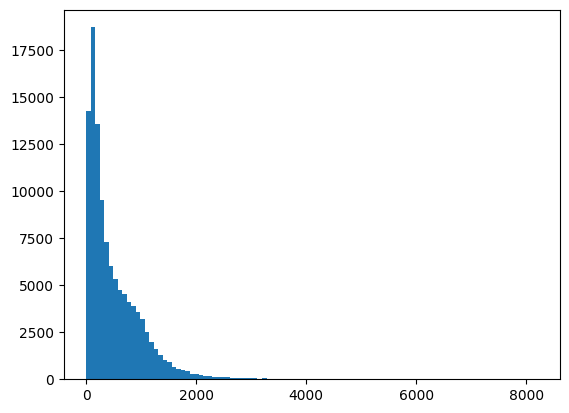

In [8]:
from FlagEmbedding import BGEM3FlagModel
from matplotlib import pyplot as plt


model = BGEM3FlagModel(
    model_name_or_path="BAAI/bge-m3",
    device="cuda",
    query_max_length=512,
    passage_max_length=8096,
    num_workers=4,
    batch_size=128,
)
plots = wiki_plots_df["plot"].tolist()
tokenized_plots = model.tokenizer(plots, padding=False, truncation=True)
wiki_plots_df["plot_token_length"] = [sum(mask) for mask in tokenized_plots["attention_mask"]]

plt.hist(wiki_plots_df["plot_token_length"], bins=100)
plt.show()



In [1]:
wiki_plots_df[wiki_plots_df["plot_token_length"] < 10]["plot_token_length"].describe()


NameError: name 'wiki_plots_df' is not defined

In [18]:
token_length = 0
with open("D:/DP/data/xml_wiki_plots.txt", "w", encoding="utf-8") as file:
    file.write("")
for index, row in wiki_plots_df[["plot", "title", "plot_token_length"]].sample(frac=0.2).iterrows():
    plot = row["plot"]
    title = row["title"]
    plot_token_length = row["plot_token_length"]
   
    with open("D:/DP/data/xml_wiki_plots.txt", "a", encoding="utf-8") as file:
        if token_length + plot_token_length > 100000:
            break
        str_title = f"<title id={title.replace(" ", "_")}>{plot}</title>\n"
        file.write(str_title)
        token_length += plot_token_length

print(token_length)

99718


# Question Lengths

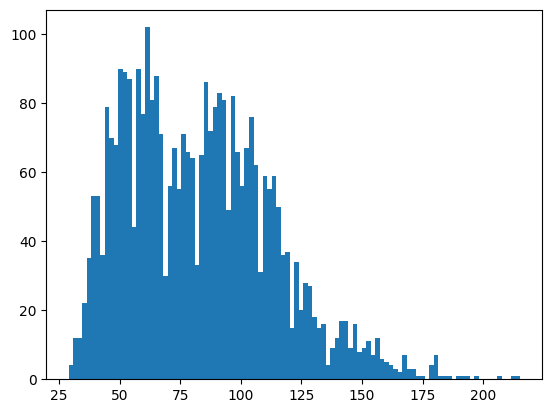

count    3316.000000
mean       83.172497
std        30.468446
min        29.000000
25%        58.000000
50%        81.000000
75%       103.000000
max       215.000000
Name: question_token_length, dtype: float64

In [28]:
qa_df = pd.read_json("D:/DP/data/movie_remakes/MovieRemakeDataset_NAACL2018/gen_data_google_gemini_2.5_pro_exp_03_25_free.jsonl", lines=True)
questions = qa_df["question"].tolist()
tokenized_questions = model.tokenizer(questions, padding=True, truncation=True)
qa_df["question_token_length"] = [sum(mask) for mask in tokenized_questions["attention_mask"]]

plt.hist(qa_df["question_token_length"], bins=100)
plt.show()

qa_df["question_token_length"].describe()

In [29]:
def to_wiki_title(title):
    return title.replace("_", " ").replace("%27", "'")

def from_wiki_title(title):
    return title.replace(" ", "_").replace("'", "%27")


all_titles = qa_df['title_id'].to_list()
all_titles.extend(qa_df["pos_title_ids"].explode()[qa_df["pos_title_ids"].explode().notna()].tolist())
all_titles.extend(qa_df["negative_title_ids"].explode()[qa_df["negative_title_ids"].explode().notna()].tolist())
all_titles = set(all_titles)
all_titles = [to_wiki_title(title) for title in all_titles]
print(len(all_titles))


3016


# Matching Wiki Plots with similarity dataset title_ids

In [30]:
wiki_plots_df[wiki_plots_df['title'].isin(all_titles)]


,plot,title,plot_length,plot_token_length
0,"Old Major, the old boar on the Manor Farm, sum...",Animal Farm,4971,1204
5,"The book tells the story of Paul Bäumer, a Ger...",All Quiet on the Western Front,4991,1216
10,"In Los Angeles in November 2019, ex-police off...",Blade Runner,4185,1065
11,"In the American Old West of 1874, construction...",Blazing Saddles,3339,902
12,Jeffrey Beaumont (Kyle MacLachlan) returns to ...,Blue Velvet (film),6046,1535
...,...,...,...,...
111548,"During a chase with armed jewel thieves, Super...",Supergirl Lives,5201,1296
111667,Vasuki (Urvashi) lives with her milkman brothe...,Vasuki (film),1209,333
111991,"The plot concerns the visit of a lieutenant, S...",Mire (short story),923,238
112692,Axel (Iraki) lives in a small town in Brindley...,Corners (film),2277,546
